In [162]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas  as pd 
import seaborn as sns

In [163]:
k=r"C:\Users\YASHVIR\Downloads\netflix_customer_churn.csv"
df=pd.read_csv(k)

In [164]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [165]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   str    
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(7)
memory usage: 920.1

In [166]:
df=df.drop(columns=["customer_id"])

In [167]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   int64  
 1   gender                  5000 non-null   str    
 2   subscription_type       5000 non-null   str    
 3   watch_hours             5000 non-null   float64
 4   last_login_days         5000 non-null   int64  
 5   region                  5000 non-null   str    
 6   device                  5000 non-null   str    
 7   monthly_fee             5000 non-null   float64
 8   churned                 5000 non-null   int64  
 9   payment_method          5000 non-null   str    
 10  number_of_profiles      5000 non-null   int64  
 11  avg_watch_time_per_day  5000 non-null   float64
 12  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(6)
memory usage: 705.3 KB


In [168]:
df.isnull().sum()

age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [169]:
df.duplicated().sum()   

np.int64(0)

In [170]:
df.head()   

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [171]:
df["gender"].unique()

<ArrowStringArray>
['Other', 'Female', 'Male']
Length: 3, dtype: str

In [172]:
df.shape

(5000, 13)

In [173]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [174]:
# encoder = OneHotEncoder(sparse_output=False)

# df = pd.get_dummies(df, columns=[
#     'gender',
#     'subscription_type',
#     'region',
#     'device',
#     'payment_method',
#     'favorite_genre'
# ])

In [175]:
df["watch_hours"]=df["watch_hours"].astype("int64")
df["avg_watch_time_per_day"]=df["avg_watch_time_per_day"].astype("int64")
df["monthly_fee"]=df["monthly_fee"].astype("int64")
df["churned"] = df["churned"].astype("int64")

In [176]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["favorite_genre"] = le.fit_transform(df["favorite_genre"])
df["gender"] = le.fit_transform(df["gender"])
df["subscription_type"]=le.fit_transform(df["subscription_type"])
df["payment_method"]=le.fit_transform(df["payment_method"])
df["device"]=le.fit_transform(df["device"])
df["region"]=le.fit_transform(df["region"])
df['churned'] = le.fit_transform(df['churned'])

In [177]:
df.drop(['last_login_days', 'avg_watch_time_per_day'], axis=1, inplace=True) 

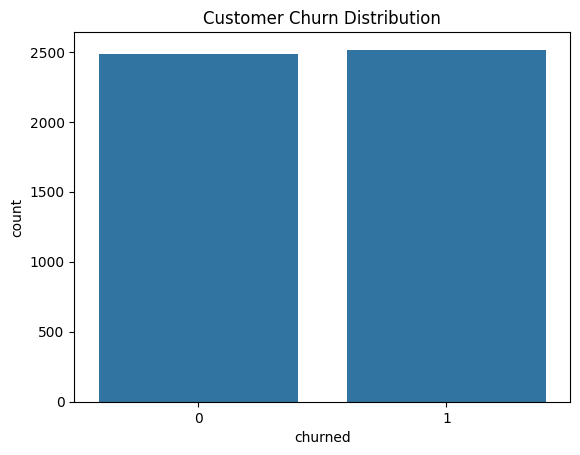

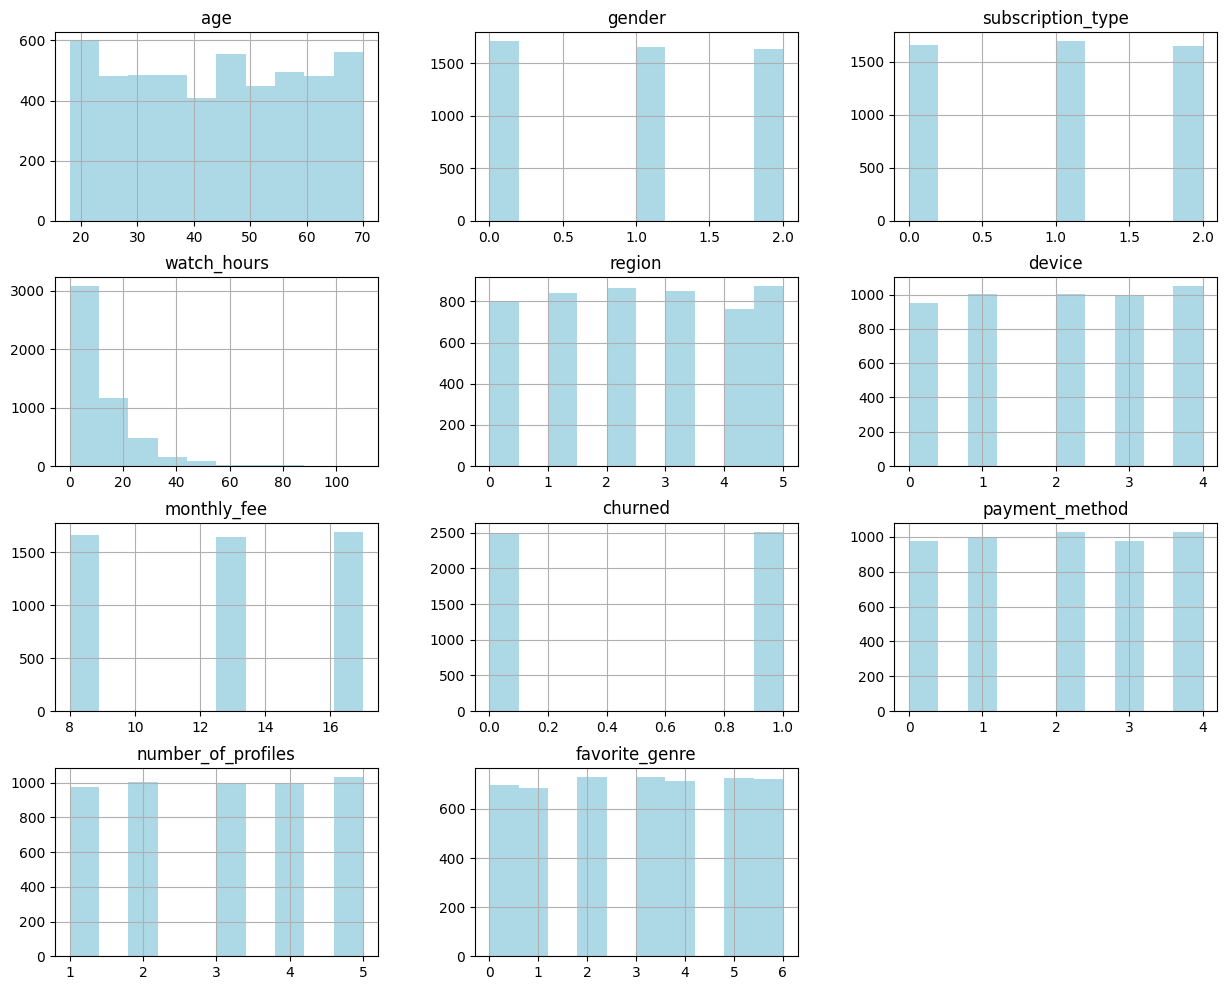

In [178]:
sns.countplot(x="churned", data=df)

plt.title("Customer Churn Distribution")
plt.show()
df.hist(figsize=(15,12),color="lightblue")
plt.show()


In [179]:
df["churned"].value_counts()

churned
1    2515
0    2485
Name: count, dtype: int64

In [180]:
X = df.drop("churned", axis=1)
y = df["churned"]

In [181]:
df["churned"].value_counts().rename({
    0:'non churn',
    1: 'churn'
})
df['churned'].value_counts(normalize=True)*100

churned
1    50.3
0    49.7
Name: proportion, dtype: float64

In [182]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix,f1_score,recall_score,precision_score,accuracy_score,roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
import plotly.express as px
import plotly.express as px
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE

In [183]:
X_train,X_test,y_train,y_test=train_test_split (
    X,y,test_size=0.3,random_state=42,stratify=y
)

In [184]:
from sklearn.pipeline import Pipeline
Scaler=StandardScaler()
X_train_scaled=Scaler.fit_transform(X_train)
X_test_scaled=Scaler.transform(X_test)

In [185]:
df.columns = df.columns.str.strip().str.lower()

In [186]:
LogisticRegression_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',LogisticRegression(random_state=42))
])
svm_rbf_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',SVC(kernel="rbf",probability=True,random_state=42))
])
svm_linear_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',SVC(kernel="linear",probability=True,random_state=42))
])

In [187]:
dt_pipeline = Pipeline([
    ('model',DecisionTreeClassifier(random_state=42
                                    ))
])
rf_pipeline = Pipeline([
    ('model',RandomForestClassifier(n_estimators=200,random_state=42))
])
xgb_pipeline = Pipeline([
    ('model',XGBClassifier(eval_metric='logloss',random_state=42))
])
lgbm_pipeline=Pipeline([
    ('model',LGBMClassifier(random_state=42))
])
catboost_pipeline=Pipeline([
    ("model",CatBoostClassifier(verbose=0,random_state=42))
])

In [188]:
models={
   "logistic regression" :LogisticRegression_pipeline,
   "xgb_model":xgb_pipeline,
   "Catboost":catboost_pipeline,
   "DecisionTreeClassifier":dt_pipeline,
   "RandomForestClassifier":rf_pipeline,
   "svm_rbf":svm_rbf_pipeline,
   "svc_linear":svm_linear_pipeline
   }

In [189]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"MODEL: {name}")
    print(f"{'='*50}")

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
        print("ROC-AUC  :", roc_auc)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Store results
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc if y_prob is not None else "Not Available"
    }


MODEL: logistic regression
Accuracy : 0.762
Precision: 0.7316219369894983
Recall   : 0.8315649867374005
F1 Score : 0.7783985102420856
ROC-AUC  : 0.8435155488867239

Confusion Matrix:
[[516 230]
 [127 627]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.69      0.74       746
           1       0.73      0.83      0.78       754

    accuracy                           0.76      1500
   macro avg       0.77      0.76      0.76      1500
weighted avg       0.77      0.76      0.76      1500


MODEL: xgb_model
Accuracy : 0.7473333333333333
Precision: 0.7388535031847133
Recall   : 0.7692307692307693
F1 Score : 0.7537361923326835
ROC-AUC  : 0.8570323778098576

Confusion Matrix:
[[541 205]
 [174 580]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.73      0.74       746
           1       0.74      0.77      0.75       754

    accuracy                           0.75 

In [190]:
model_results=pd.DataFrame(results)
model_results = model_results.transpose().sort_values(by="F1 Score", ascending=False)
print(model_results)

                        Accuracy  Precision    Recall  F1 Score   ROC-AUC
svc_linear              0.765333   0.731567  0.842175  0.782984  0.844586
logistic regression     0.762000   0.731622  0.831565  0.778399  0.843516
Catboost                0.764000   0.765252  0.765252  0.765252  0.870875
RandomForestClassifier  0.759333   0.752246  0.777188  0.764514  0.870927
svm_rbf                 0.746667   0.724221  0.801061  0.760705  0.841357
xgb_model               0.747333   0.738854  0.769231  0.753736  0.857032
DecisionTreeClassifier  0.732000   0.723919  0.754642  0.738961  0.731879


In [191]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print(scores.mean())

0.7434000000000001


In [192]:
print(df.corr(numeric_only=True)['churned'].sort_values(ascending=False))

churned               1.000000
payment_method        0.012535
region                0.011231
device               -0.001148
age                  -0.003515
gender               -0.010648
favorite_genre       -0.026492
subscription_type    -0.133517
monthly_fee          -0.152117
number_of_profiles   -0.158614
watch_hours          -0.480526
Name: churned, dtype: float64


In [193]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [194]:
from sklearn.model_selection import GridSearchCV

log_param = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

log_grid = GridSearchCV(
    LogisticRegression_pipeline,
    log_param,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

log_grid.fit(X_train, y_train)

print(log_grid.best_params_)
print(log_grid.best_score_)

{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
0.7414285714285714


C:\Users\YASHVIR\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [195]:
svm_rbf_param = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 'auto', 0.01, 0.001],
    'model__kernel': ['rbf']
}

svm_rbf_grid = GridSearchCV(
    svm_rbf_pipeline,
    svm_rbf_param,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svm_rbf_grid.fit(X_train, y_train)

print(svm_rbf_grid.best_params_)
print(svm_rbf_grid.best_score_)

{'model__C': 1, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
0.7362857142857142


In [196]:
rf_param = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15],
    'model__min_samples_split': [5, 10],
    'model__min_samples_leaf': [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
0.7522857142857142


In [197]:
cat_param = {
    'model__depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__iterations': [100, 200]
}

cat_grid = GridSearchCV(
    catboost_pipeline,
    cat_param,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

cat_grid.fit(X_train, y_train)

print(cat_grid.best_params_)
print(cat_grid.best_score_)

{'model__depth': 4, 'model__iterations': 100, 'model__learning_rate': 0.1}
0.762


In [198]:
xgb_param = {
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__n_estimators': [100, 200]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_param,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print(xgb_grid.best_params_)
print(xgb_grid.best_score_)

{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
0.7605714285714286


In [199]:
svm_linear_param = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__kernel': ['linear']
}

svm_linear_grid = GridSearchCV(
    svm_linear_pipeline,
    svm_linear_param,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svm_linear_grid.fit(X_train, y_train)

print(svm_linear_grid.best_params_)
print(svm_linear_grid.best_score_)

{'model__C': 10, 'model__kernel': 'linear'}
0.7411428571428571


In [200]:
tuned_models = {
    "Logistic Regression": log_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "SVM RBF": svm_rbf_grid.best_estimator_,
    "SVM Linear": svm_linear_grid.best_estimator_,
    "CatBoost": cat_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_,
    
}

results = []

for name, model in tuned_models.items():
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
3           SVM Linear  0.765333   0.731567  0.842175  0.782984  0.844650
4             CatBoost  0.764667   0.762779  0.771883  0.767304  0.871571
0  Logistic Regression  0.762000   0.731622  0.831565  0.778399  0.843516
2              SVM RBF  0.758000   0.721404  0.844828  0.778253  0.847443
5              XGBoost  0.754667   0.765110  0.738727  0.751687  0.866927
1        Random Forest  0.752000   0.775216  0.713528  0.743094  0.869861


In [201]:
best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(),'Model']

print("Best Model:", best_model_name)
# print("Model Name :", best_model['Model'])
# print("Accuracy   :", best_model['Accuracy'])
# print("Precision  :", best_model['Precision'])
# print("Recall     :", best_model['Recall'])
# print("F1 Score   :", best_model['F1 Score'])
# print("ROC-AUC    :", best_model['ROC-AUC'])

Best Model: CatBoost


In [202]:
best_model = tuned_models[best_model_name]

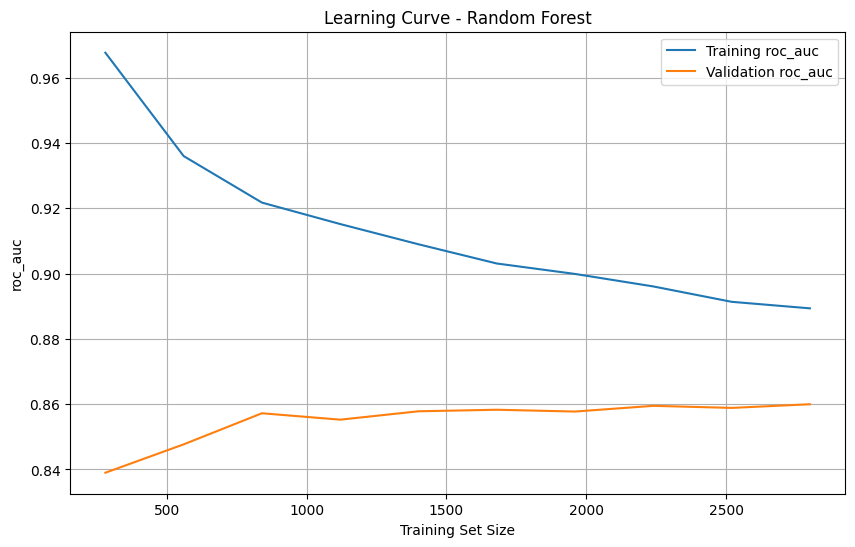

In [203]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(
    rf_grid.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plot
plt.figure(figsize=(10,6))

plt.plot(train_sizes, train_mean, label='Training roc_auc')
plt.plot(train_sizes, test_mean, label='Validation roc_auc')

plt.title("Learning Curve - Random Forest")
plt.xlabel("Training Set Size")
plt.ylabel("roc_auc")
plt.legend()
plt.grid(True)

plt.show()

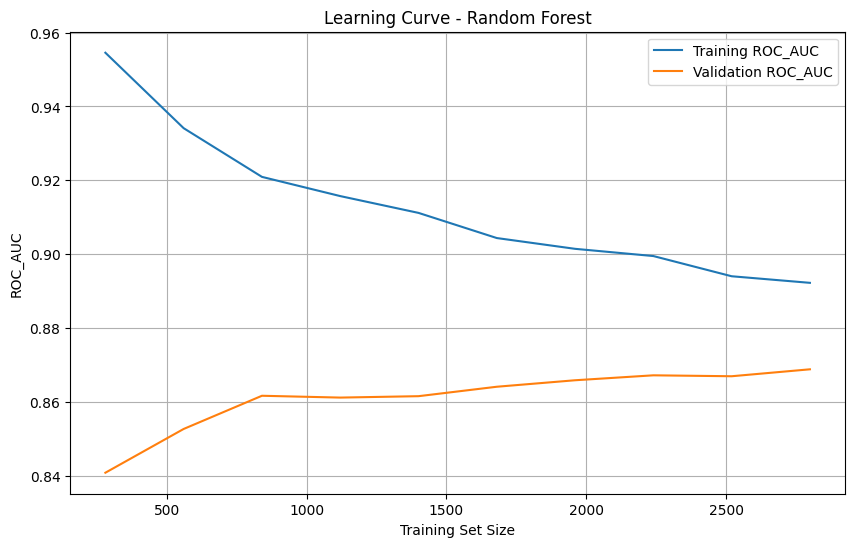

In [204]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(
    cat_grid.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plot
plt.figure(figsize=(10,6))

plt.plot(train_sizes, train_mean, label='Training ROC_AUC')
plt.plot(train_sizes, test_mean, label='Validation ROC_AUC')

plt.title("Learning Curve - Random Forest")
plt.xlabel("Training Set Size")
plt.ylabel("ROC_AUC")
plt.legend()
plt.grid(True)

plt.show()

In [205]:
y_train_pred = rf_grid.best_estimator_.predict(X_train)
y_test_pred = rf_grid.best_estimator_.predict(X_test)

# roc_aucuracy
train_roc_auc = roc_auc_score(y_train, y_train_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred)

print("Training ROC-AUC:", train_roc_auc)
print("Testing ROC-AUC:", test_roc_auc)

# Overfitting check
if train_roc_auc - test_roc_auc > 0.10:
    print("⚠️ Model is likely OVERFITTING")
else:
    print("✅ Model is OK (no major overfitting)")

Training ROC-AUC: 0.767821683730198
Testing ROC-AUC: 0.7522062849787727
✅ Model is OK (no major overfitting)


In [206]:
y_train_pred = cat_grid.best_estimator_.predict(X_train)
y_test_pred = cat_grid.best_estimator_.predict(X_test)

# roc_aucuracy
train_roc_auc = roc_auc_score(y_train, y_train_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred)

print("Training ROC-AUC:", train_roc_auc)
print("Testing ROC-AUC:", test_roc_auc)

if train_roc_auc - test_roc_auc > 0.10:
    print("⚠️ Model is likely OVEFIITTING")
else:
    print("✅ Model is OK (no major ovefititting)")

Training ROC-AUC: 0.7857094108861117
Testing ROC-AUC: 0.7646279716400822
✅ Model is OK (no major ovefititting)


In [207]:
# import joblib

# joblib.dump(rf_grid.best_estimator_, r"C:\Users\YASHVIR\OneDrive\Attachments\netflix/model.joblib")

In [208]:
import pickle
with open(r"C:\Users\YASHVIR\OneDrive\Attachments\netflix\model.pkl","wb")as f:

  pickle.dump(best_model,f)
